# 静态场景 - 密度扫描实验
固定业务比例，扫描不同总密度下的性能表现

## 初始化环境

In [1]:
import sys
sys.path.insert(0, '.')

from algo.logger import reset_logger
reset_logger()

In [2]:
from dataclasses import replace
from pathlib import Path
from typing import Dict
from copy import deepcopy
import math
import torch
import yaml
import os
import numpy as np
from collections import OrderedDict
import importlib
from matplotlib import pyplot as plt

from algo import HPPOConfig, build_hppo_modules, train_hppo
from algo.logger import get_logger, setup_logger
from env import (
    MACSimulatorConfig,
    SatelliteMACEnv,
    SatelliteMACEnvConfig,
    default_simulator_config,
    build_gym_env,
)
import matplotlib.font_manager as font_manager
import scienceplots
plt.style.use(['science', 'no-latex'])
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['Noto Sans SC',]

# 导入评估工具（使用新的分离函数）
from utils.evaluate import (
    static_sensitivity_config,
    train_scenario,
    evaluate_scenario_ppo,
    evaluate_scenario_baseline,
    print_results_summary,
    load_yaml_config
)
import baseline
importlib.reload(baseline)
from baseline import run_episode


## 密度扫描配置生成

In [3]:
def run_density_sweep_experiment():
    """
    密度扫描实验：固定业务比例，扫描总密度
    用于绘制：Throughput vs. Density 曲线
    """
    # 1. 定义几个固定的业务混合模式
    traffic_mixes = {
        "Balanced": {'cbra': 0.4, 'pbra': 0.35, 'cfra': 0.25},
    }

    # 2. 定义要扫描的密度范围
    densities = [5.0, 10.0, 25.0, 40.0]
    configs = []

    print("--- Generating Density Sweep Configs ---")
    for mix_name, ratios in traffic_mixes.items():
        for d in densities:
            cfg = static_sensitivity_config(
                total_density=d,
                cbra_ratio=ratios['cbra'],
                pbra_ratio=ratios['pbra'],
                cfra_ratio=ratios['cfra']
            )
            label = f"{mix_name}_D{int(d)}"
            configs.append((label, cfg))
            print(f"Generated: [{label}]")

    return configs

# 生成配置
density_sweep_configs = run_density_sweep_experiment()
print(f"\n总共生成 {len(density_sweep_configs)} 个密度扫描场景配置")

--- Generating Density Sweep Configs ---
Generated: [Balanced_D5]
Generated: [Balanced_D10]
Generated: [Balanced_D25]
Generated: [Balanced_D40]

总共生成 4 个密度扫描场景配置


## 加载训练配置

In [4]:
CONFIG_PATH = Path("conf/default.yaml")

raw_config = load_yaml_config(CONFIG_PATH)
seed = int(raw_config.get("seed", 20251202))
torch.manual_seed(seed)

log_section = raw_config.get("logging", {})
log_file = f"logs/{seed}_density_sweep_Balanced.log"
try:
    os.remove(log_file) if os.path.exists(log_file) else None
except Exception as e:
    print(f"Warning: Could not remove existing log file: {e}")
log_level = log_section.get("level", "INFO")
setup_logger(log_file, log_level)
my_logger = get_logger()
my_logger.info(f"Logger initialized for density sweep experiment")

# 环境配置
env_section = dict(raw_config.get("environment", {}))
algo_section = raw_config.get("algorithm", {})
env_section.setdefault("noise_scale", 0.01)

simulator_config = default_simulator_config()
num_slots_per_step = int(env_section.get("num_slots_per_step", 10))

env_config = SatelliteMACEnvConfig(
    num_slots_per_step=10,
    decision_horizon=100,
    preamble_delta_range=int(env_section.get("preamble_delta_range", 2)),
    flatten_observation=bool(env_section.get("flatten_observation", True)),
    simulator_config=simulator_config,
)

num_envs = 8
env_backend = "parallel"

train_config = HPPOConfig(
    frames_per_batch=3200,
    mini_batch_size=256,
    rollout_epochs=4,
    max_iterations=2000,  # 静态场景训练100轮
    gamma=float(algo_section.get("gamma", 0.99)),
    gae_lambda=float(algo_section.get("gae_lambda", 0.95)),
    clip_epsilon=0.2,
    entropy_coeff=0.1,
    actor_lr=3e-4,
    critic_lr=3e-4,
    device=torch.device(algo_section.get("device", "cpu")),
)

my_logger.info(f"Config ready | seed={seed} num_envs={num_envs}")
print(f"配置加载完成: {len(density_sweep_configs)} 个场景待训练")


2025-12-04 23:31:11 | INFO     | Logger initialized for density sweep experiment


Loaded configuration from conf\default.yaml
配置加载完成: 4 个场景待训练


2025-12-04 23:31:11 | INFO     | Config ready | seed=42 num_envs=8


## 执行密度扫描训练

In [ ]:
all_train_results = OrderedDict()  # 存储训练结果

In [ ]:
print(f"\n{'='*80}")
print(f"开始批量训练 {len(density_sweep_configs)} 个密度扫描场景")
print(f"{'='*80}\n")

for idx, (label, sim_config) in enumerate(density_sweep_configs):
    print(f"\n[{idx+1}/{len(density_sweep_configs)}] 当前场景: {label}")
    try:
        # 训练模型
        train_result = train_scenario(
            scenario_name=label,
            sim_config=sim_config,
            env_config=env_config,
            train_config=train_config,
            build_env_func=build_gym_env,
            build_modules_func=build_hppo_modules,
            train_func=train_hppo,
            logger=my_logger,
            num_envs=num_envs,
            env_backend=env_backend,
            seed=seed
        )

        all_train_results[label] = train_result
        print(f"✓ 场景 {label} 训练完成")

    except Exception as e:
        print(f"✗ 场景 {label} 训练失败: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*80}")
print(f"所有场景训练完成!")
print(f"成功训练场景数: {len(all_train_results)}/{len(density_sweep_configs)}")
print(f"{'='*80}")



开始批量训练 4 个密度扫描场景


[1/4] 当前场景: Balanced_D10

开始训练场景: Balanced_D10
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=100, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D10.0_C0.4_P0.3_F0.2', cbra_density=4.0, pbra_density=3.5, cfra_density=2.5),), segments=(RegionSegment(region_name='static_D10.0_C0.4_P0.3_F0.2', length=13.0),), total_preambles=64, base_preamble_split=(27, 27, 10), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_scale=0.05, reward_weights={'throughput': 1.0, 'collision': -0.3}, backoff_strategy=BackoffStrategyConfig(low=BackoffWindow(min_steps=0, max_steps=4), medium=BackoffWindow(min_steps=2, max_steps=10), high=BackoffWindow(min_steps=6, max_steps=18), collision_threshold_medium=0.08, collision_threshold_high=0.16, max_backlog_steps=48)), preamble_delta_range=2, flatten_observation=True)
config 2
2025-12-05 10:08:46,984 [torchrl][INFO]    The info_dict_reader does not have specs. The o

2025-12-05 10:08:47,003 [torchrl][INFO]    check_env_specs succeeded! [END]


e:\CourseData\博士\二上\i3c\20251027-星网总结报告\hppo-mac\.venv\Lib\site-packages\torchrl\envs\batched_envs.py:2318: UserWarning: Sending a seeded ParallelEnv to another device requires re-seeding it. Re-seeding envs to [42, 1445067485, 3334094167, 3585780589, 2792652595, 3481998204, 395747745, 79072177].
  warn(
2025-12-05 10:08:50 | INFO     | Starting PPO training for scenario: Balanced_D10


  iter=0000, reward=-0.9888
  iter=0010, reward=0.6537
  iter=0020, reward=0.9920
  iter=0030, reward=1.2514
  iter=0040, reward=1.4167
  iter=0050, reward=1.5184
  iter=0060, reward=1.5661
  iter=0070, reward=1.5967
  iter=0080, reward=1.6153
  iter=0090, reward=1.7468
  iter=0100, reward=1.7839
  iter=0110, reward=1.6717
  iter=0120, reward=1.8028
  iter=0130, reward=1.7189
  iter=0140, reward=1.7707
  iter=0150, reward=1.8089
  iter=0160, reward=1.8708
  iter=0170, reward=1.8278
  iter=0180, reward=1.8630
  iter=0190, reward=1.8700
  iter=0200, reward=1.8953
  iter=0210, reward=1.9240
  iter=0220, reward=1.9045
  iter=0230, reward=1.9123
  iter=0240, reward=1.9348
  iter=0250, reward=1.9269
  iter=0260, reward=1.9647
  iter=0270, reward=1.9166
  iter=0280, reward=1.9318
  iter=0290, reward=1.9781
  iter=0300, reward=1.9888
  iter=0310, reward=1.9961
  iter=0320, reward=1.9730
  iter=0330, reward=2.0010
  iter=0340, reward=2.0424
  iter=0350, reward=1.9528
  iter=0360, reward=1.9911


## 可视化密度扫描结果

In [6]:
import utils.evaluate as eval_module  # 使用别名
importlib.reload(eval_module)  # 重载别名
from utils.evaluate import evaluate_scenario_ppo, evaluate_scenario_baseline

In [ ]:
# 评估所有训练好的模型
all_scenarios_results = OrderedDict()

print(f"\n{'='*80}")
print(f"开始评估 {len(all_train_results)} 个训练好的场景")
print(f"{'='*80}\n")

for idx, (label, train_result) in enumerate(all_train_results.items()):
    print(f"\n[{idx+1}/{len(all_train_results)}] 评估场景: {label}")
    try:
        # 第一步：评估PPO模型（best和last）
        ppo_eval_result = evaluate_scenario_ppo(
            scenario_name=label,
            scenario_env_config=train_result['env_config'],
            actor=train_result['actor'],
            critic=train_result['critic'],
            rl_env=train_result['rl_env'],
            best_model=train_result['best_model'],
            last_model=train_result['last_model'],
            num_episodes=20,
            seed=seed
        )

        # 第二步：评估baseline策略
        baseline_eval_result = evaluate_scenario_baseline(
            scenario_name=label,
            scenario_env_config=train_result['env_config'],
            run_episode_func=run_episode,
            num_episodes=20,
            seed=seed
        )

        # 合并结果
        result = {
            'train_rewards': [m['reward'] for m in train_result['metrics_history']],
            'eval_results_best': ppo_eval_result['eval_results_best'],
            'eval_results_last': ppo_eval_result['eval_results_last'],
            'baseline_results': baseline_eval_result['baseline_results']
        }

        all_scenarios_results[label] = result
        print(f"✓ 场景 {label} 评估完成")

    except Exception as e:
        print(f"✗ 场景 {label} 评估失败: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*80}")
print(f"所有场景评估完成!")
print(f"成功评估场景数: {len(all_scenarios_results)}/{len(all_train_results)}")
print(f"{'='*80}")

# 显示结果摘要
print_results_summary(all_scenarios_results)


In [ ]:
# # 如果中间有训练炸了重训得重新建立环境
# all_scenarios_results = OrderedDict()

# print(f"\n{'='*80}")
# print(f"开始评估 {len(all_train_results)} 个训练好的场景")
# print(f"{'='*80}\n")

# for idx, (label, train_result) in enumerate(all_train_results.items()):
#     print(f"\n[{idx+1}/{len(all_train_results)}] 评估场景: {label}")
#     try:
#         # 关键修复：为评估重新构建一个环境实例，而不是复用可能已失效的训练环境
#         from torchrl.envs import ParallelEnv, SerialEnv, TransformedEnv
#         from torchrl.envs.transforms import Compose, DoubleToFloat
#         sim_config = density_sweep_configs[idx]
#         scenario_env_config = train_result['env_config']
#         def _make_scenario_env(rank: int = 0, **_: object):
#             env_seed = seed + rank if seed is not None else None
#             wrapped = build_gym_env(config=deepcopy(scenario_env_config))
#             wrapped.set_seed(env_seed)
#             wrapped.auto_register_info_dict()
#             return wrapped
#         if num_envs <= 1:
#             scenario_base_env = _make_scenario_env(0)
#         else:
#             if env_backend == "parallel":
#                 scenario_base_env = ParallelEnv(num_envs, _make_scenario_env)
#             else:
#                 scenario_base_env = SerialEnv(num_envs, _make_scenario_env, auto_reset=True)

#         scenario_transforms = Compose(DoubleToFloat())
#         scenario_rl_env = TransformedEnv(scenario_base_env, scenario_transforms)
#         if seed is not None:
#             scenario_rl_env.set_seed(seed)
#         scenario_rl_env.to(train_config.device)
#         # 第一步：评估PPO模型（best和last）
#         ppo_eval_result = evaluate_scenario_ppo(
#             scenario_name=label,
#             scenario_env_config=train_result['env_config'],
#             actor=train_result['actor'],
#             critic=train_result['critic'],
#             rl_env=scenario_rl_env,
#             best_model=train_result['best_model'],
#             last_model=train_result['last_model'],
#             num_episodes=20,
#             seed=seed
#         )

#         # 第二步：评估baseline策略
#         baseline_eval_result = evaluate_scenario_baseline(
#             scenario_name=label,
#             scenario_env_config=train_result['env_config'],
#             run_episode_func=run_episode,
#             num_episodes=20,
#             seed=seed,
#             preamble_init = (24,24,16)
#         )

#         # 合并结果
#         result = {
#             'train_rewards': [m['reward'] for m in train_result['metrics_history']],
#             'eval_results_best': ppo_eval_result['eval_results_best'],
#             'eval_results_last': ppo_eval_result['eval_results_last'],
#             'baseline_results': baseline_eval_result['baseline_results']
#         }

#         all_scenarios_results[label] = result
#         print(f"✓ 场景 {label} 评估完成")

#     except Exception as e:
#         print(f"✗ 场景 {label} 评估失败: {e}")
#         import traceback
#         traceback.print_exc()
#         continue

# print(f"\n{'='*80}")
# print(f"所有场景评估完成!")
# print(f"成功评估场景数: {len(all_scenarios_results)}/{len(all_train_results)}")
# print(f"{'='*80}")

# # 显示结果摘要
# print_results_summary(all_scenarios_results)



开始评估 4 个训练好的场景


[1/4] 评估场景: Balanced_D5
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=100, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D5.0_C0.4_P0.3_F0.2', cbra_density=2.0, pbra_density=1.75, cfra_density=1.25),), segments=(RegionSegment(region_name='static_D5.0_C0.4_P0.3_F0.2', length=13.0),), total_preambles=64, base_preamble_split=(27, 27, 10), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_scale=0.05, reward_weights={'throughput': 1.0, 'collision': -0.3}, backoff_strategy=BackoffStrategyConfig(low=BackoffWindow(min_steps=0, max_steps=4), medium=BackoffWindow(min_steps=2, max_steps=10), high=BackoffWindow(min_steps=6, max_steps=18), collision_threshold_medium=0.08, collision_threshold_high=0.16, max_backlog_steps=48)), preamble_delta_range=2, flatten_observation=True)
config 2
2025-12-05 11:54:05,762 [torchrl][INFO]    The info_dict_reader does not have specs. The only way to palliate to th

e:\CourseData\博士\二上\i3c\20251027-星网总结报告\hppo-mac\.venv\Lib\site-packages\torchrl\envs\batched_envs.py:2318: UserWarning: Sending a seeded ParallelEnv to another device requires re-seeding it. Re-seeding envs to [42, 1445067485, 3334094167, 3585780589, 2792652595, 3481998204, 395747745, 79072177].
  warn(



评估场景 Balanced_D5 的PPO模型...
  评估最佳模型...
  评估最后一轮模型...
  评估最后一轮模型...
  PPO最佳奖励: 219.4252
  PPO最后奖励: 149.5883

评估场景 Balanced_D5 的Baseline策略...
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=100, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D5.0_C0.4_P0.3_F0.2', cbra_density=2.0, pbra_density=1.75, cfra_density=1.25),), segments=(RegionSegment(region_name='static_D5.0_C0.4_P0.3_F0.2', length=13.0),), total_preambles=64, base_preamble_split=(27, 27, 10), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_scale=0.05, reward_weights={'throughput': 1.0, 'collision': -0.3}, backoff_strategy=BackoffStrategyConfig(low=BackoffWindow(min_steps=0, max_steps=4), medium=BackoffWindow(min_steps=2, max_steps=10), high=BackoffWindow(min_steps=6, max_steps=18), collision_threshold_medium=0.08, collision_threshold_high=0.16, max_backlog_steps=48)), preamble_delta_range=2, flatten_observation=False)
config 2
  运行固定分配基线...
 

## 评估训练好的模型

Balanced_D5 eval_results_best
Balanced_D10 eval_results_last
Balanced_D25 eval_results_best
Balanced_D40 eval_results_last


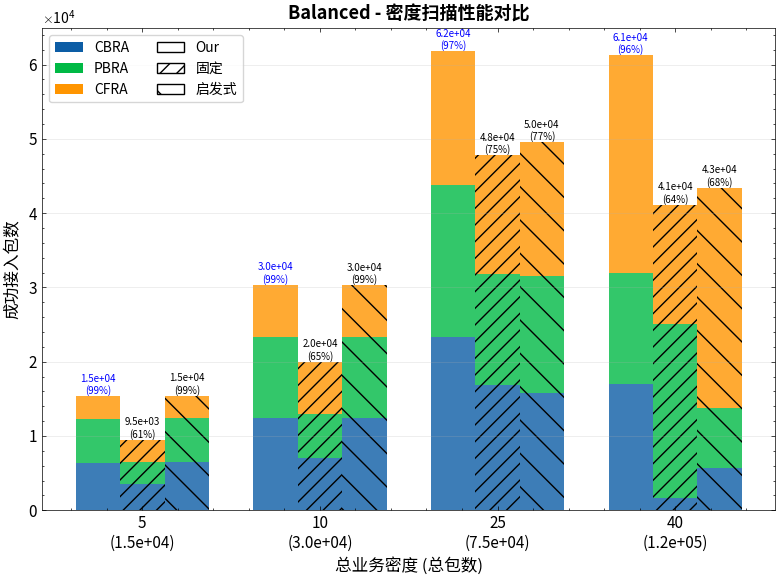

密度扫描对比图已保存到: output/static/density_sweep_Balanced.svg


In [21]:
def plot_density_sweep_results():
    """绘制密度扫描实验结果 - 单个流量模式的图"""
    traffic_mixes = ["Balanced"]
    densities = [5.0, 10.0, 25.0, 40.0]

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    for mix_idx, mix_name in enumerate(traffic_mixes):
        # 收集数据
        ppo_cbra = []
        ppo_pbra = []
        ppo_cfra = []
        ppo_theo = []
        ppo_arrivals = []
        fixed_cbra = []
        fixed_pbra = []
        fixed_cfra = []
        fixed_theo = []
        fixed_arrivals = []
        heuristic_cbra = []
        heuristic_pbra = []
        heuristic_cfra = []
        heuristic_theo = []
        heuristic_arrivals = []
        total_arrivals_list = []

        for d in densities:
            label = f"{mix_name}_D{int(d)}"
            if label in all_scenarios_results:
                result = all_scenarios_results[label]

                # PPO最佳模型，在训练次数少的时候，best有时候不如last
                ppo_choice = None
                best_total_succ = (result['eval_results_best']['eval_success_cbra'] + result['eval_results_best']['eval_success_pbra'] + result['eval_results_best']['eval_success_cfra'])
                last_total_succ = (result['eval_results_last']['eval_success_cbra'] + result['eval_results_last']['eval_success_pbra'] + result['eval_results_last']['eval_success_cfra'])
                ppo_choice = 'eval_results_best' if best_total_succ >= last_total_succ else 'eval_results_last'
                print(label, ppo_choice)

                # PPO结果
                ppo_cbra.append(result[ppo_choice]['eval_success_cbra'])
                ppo_pbra.append(result[ppo_choice]['eval_success_pbra'])
                ppo_cfra.append(result[ppo_choice]['eval_success_cfra'])
                ppo_theo.append(result[ppo_choice].get('eval_theoretical_optimal', 0))
                # PPO arrivals（用于密度较小场景的分母）
                ppo_arrivals.append(
                    result[ppo_choice].get('eval_arrivals_cbra', 0) +
                    result[ppo_choice].get('eval_arrivals_pbra', 0) +
                    result[ppo_choice].get('eval_arrivals_cfra', 0)
                )

                # 固定分配
                fixed_cbra.append(result['baseline_results']['固定分配']['success_cbra'])
                fixed_pbra.append(result['baseline_results']['固定分配']['success_pbra'])
                fixed_cfra.append(result['baseline_results']['固定分配']['success_cfra'])
                fixed_theo.append(result['baseline_results']['固定分配'].get('theoretical_optimal', 0))
                fixed_arrivals.append(
                    result['baseline_results']['固定分配'].get('arrivals_cbra', 0) +
                    result['baseline_results']['固定分配'].get('arrivals_pbra', 0) +
                    result['baseline_results']['固定分配'].get('arrivals_cfra', 0)
                )

                # 启发式算法
                heuristic_cbra.append(result['baseline_results']['启发式算法']['success_cbra'])
                heuristic_pbra.append(result['baseline_results']['启发式算法']['success_pbra'])
                heuristic_cfra.append(result['baseline_results']['启发式算法']['success_cfra'])
                heuristic_theo.append(result['baseline_results']['启发式算法'].get('theoretical_optimal', 0))
                heuristic_arrivals.append(
                    result['baseline_results']['启发式算法'].get('arrivals_cbra', 0) +
                    result['baseline_results']['启发式算法'].get('arrivals_pbra', 0) +
                    result['baseline_results']['启发式算法'].get('arrivals_cfra', 0)
                )

                # 获取总到达包数 (使用固定分配的到达数作为参考)
                total_arr = (result['baseline_results']['固定分配']['arrivals_cbra'] +
                           result['baseline_results']['固定分配']['arrivals_pbra'] +
                           result['baseline_results']['固定分配']['arrivals_cfra'])
                total_arrivals_list.append(total_arr)
            else:
                ppo_cbra.append(0)
                ppo_pbra.append(0)
                ppo_cfra.append(0)
                ppo_theo.append(0)
                ppo_arrivals.append(0)
                fixed_cbra.append(0)
                fixed_pbra.append(0)
                fixed_cfra.append(0)
                fixed_theo.append(0)
                fixed_arrivals.append(0)
                heuristic_cbra.append(0)
                heuristic_pbra.append(0)
                heuristic_cfra.append(0)
                heuristic_theo.append(0)
                heuristic_arrivals.append(0)
                total_arrivals_list.append(0)

        ppo_cbra = np.array(ppo_cbra)
        ppo_pbra = np.array(ppo_pbra)
        ppo_cfra = np.array(ppo_cfra)
        ppo_theo = np.array(ppo_theo)
        ppo_arrivals = np.array(ppo_arrivals)
        fixed_cbra = np.array(fixed_cbra)
        fixed_pbra = np.array(fixed_pbra)
        fixed_cfra = np.array(fixed_cfra)
        fixed_theo = np.array(fixed_theo)
        fixed_arrivals = np.array(fixed_arrivals)
        heuristic_cbra = np.array(heuristic_cbra)
        heuristic_pbra = np.array(heuristic_pbra)
        heuristic_cfra = np.array(heuristic_cfra)
        heuristic_theo = np.array(heuristic_theo)
        heuristic_arrivals = np.array(heuristic_arrivals)

        ppo_total = ppo_cbra + ppo_pbra + ppo_cfra
        fixed_total = fixed_cbra + fixed_pbra + fixed_cfra
        heuristic_total = heuristic_cbra + heuristic_pbra + heuristic_cfra

        # 绘制堆叠柱状图
        x = np.arange(len(densities))
        width = 0.25

        # Our (最佳) - 实心
        p1_cbra = ax.bar(x - width, ppo_cbra, width, alpha=0.8, color='C0')
        p1_pbra = ax.bar(x - width, ppo_pbra, width, bottom=ppo_cbra, alpha=0.8, color='C1')
        p1_cfra = ax.bar(x - width, ppo_cfra, width, bottom=ppo_cbra+ppo_pbra, alpha=0.8, color='C2')

        # 固定分配 - 斜线填充
        p2_cbra = ax.bar(x, fixed_cbra, width, alpha=0.8, color='C0', hatch='//')
        p2_pbra = ax.bar(x, fixed_pbra, width, bottom=fixed_cbra, alpha=0.8, color='C1', hatch='//')
        p2_cfra = ax.bar(x, fixed_cfra, width, bottom=fixed_cbra+fixed_pbra, alpha=0.8, color='C2', hatch='//')

        # 启发式算法 - 反斜线填充
        p3_cbra = ax.bar(x + width, heuristic_cbra, width, alpha=0.8, color='C0', hatch='\\')
        p3_pbra = ax.bar(x + width, heuristic_pbra, width, bottom=heuristic_cbra, alpha=0.8, color='C1', hatch='\\')
        p3_cfra = ax.bar(x + width, heuristic_cfra, width, bottom=heuristic_cbra+heuristic_pbra, alpha=0.8, color='C2', hatch='\\')

        # 标注总数和达最优率
        for i in range(len(densities)):
            # 当密度较小时 (例如 <22)，分母使用对应方法的到达数据；否则使用理论最优(theoretical_optimal)
            density_val = densities[i]

            if ppo_total[i] > 0:
                denom = ppo_arrivals[i] if density_val < 22 else ppo_theo[i]
                theo_rate = (ppo_total[i] / denom * 100) if denom > 0 else 0
                ax.text(i - width, ppo_total[i], f'{ppo_total[i]:.1e}\n({theo_rate:.0f}%)',
                       ha='center', va='bottom', fontsize=7, color='blue')
            if fixed_total[i] > 0:
                denom = fixed_arrivals[i] if density_val < 22 else fixed_theo[i]
                theo_rate = (fixed_total[i] / denom * 100) if denom > 0 else 0
                ax.text(i, fixed_total[i], f'{fixed_total[i]:.1e}\n({theo_rate:.0f}%)',
                       ha='center', va='bottom', fontsize=7)
            if heuristic_total[i] > 0:
                denom = heuristic_arrivals[i] if density_val < 22 else heuristic_theo[i]
                theo_rate = (heuristic_total[i] / denom * 100) if denom > 0 else 0
                ax.text(i + width, heuristic_total[i], f'{heuristic_total[i]:.1e}\n({theo_rate:.0f}%)',
                       ha='center', va='bottom', fontsize=7)

        ax.set_xlabel('总业务密度 (总包数)', fontsize=12)
        ax.set_ylabel('成功接入包数', fontsize=12)
        ax.set_title(f'{mix_name} - 密度扫描性能对比', fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        # 横轴标签添加总包数信息
        xticklabels = [f'{int(d)}\n({int(arr):.1e})' if arr > 0 else f'{int(d)}'
                      for d, arr in zip(densities, total_arrivals_list)]
        ax.set_xticklabels(xticklabels, fontsize=10)

        # 添加图例
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='C0', label='CBRA'),
            Patch(facecolor='C1', label='PBRA'),
            Patch(facecolor='C2', label='CFRA'),
            Patch(facecolor='white', edgecolor='black', label='Our'),
            Patch(facecolor='white', edgecolor='black', hatch='//', label='固定'),
            Patch(facecolor='white', edgecolor='black', hatch='\\', label='启发式'),
        ]
        ax.legend(handles=legend_elements, fontsize=10, frameon=True, loc='upper left', ncol=2)

        ax.tick_params(labelsize=11)
        ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
        ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    os.makedirs("output/static", exist_ok=True)
    plt.savefig("output/static/density_sweep_Balanced.svg", bbox_inches='tight', dpi=300)
    plt.show()
    print("密度扫描对比图已保存到: output/static/density_sweep_Balanced.svg")

# 绘制结果
plot_density_sweep_results()


In [22]:
import os
import json
import numpy as np

def make_serializable(obj):
    """Recursively convert numpy types and arrays into Python built-ins for JSON serialization."""
    if isinstance(obj, dict):
        return {k: make_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_serializable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    return obj

os.makedirs('output/static', exist_ok=True)
out_path = os.path.join('output', 'static', 'balanced_scenarios_results.json')
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(make_serializable(all_scenarios_results), f, ensure_ascii=False, indent=2)
print(f"Saved all_scenarios_results -> {out_path}")


Saved all_scenarios_results -> output\static\balanced_scenarios_results.json
